# 3. Ordinary Kriging 



**Dataset:** Jura geochemical survey (`data/jura_data.csv`, `data/jura_grid.csv`)  

**Target:** Cadmium (Cd, mg/kg) 
 
**Library:** `pygstat` v0.1.0  



***

## Table of Contents

1. [Overview](#1-overview)
2. [What is Ordinary Kriging?](#2-what-is-ordinary-kriging)
3. [How Ordinary Kriging Works](#3-how-ordinary-kriging-works)
4. [Python Setup](#4-python-setup)
   - 4.1 [CPU and GPU](#41-cpu-and-gpu)
5. [Load and Explore the Jura Data](#5-load-and-explore-the-jura-data)
6. [Stratified Train / Test Split](#6-stratified-train--test-split)
7. [Variogram Modeling on Training Data](#7-variogram-modeling-on-training-data)
8. [Fit Ordinary Kriging](#8-fit-ordinary-kriging)
9. [Validate OK on the Test Set](#9-validate-ok-on-the-test-set)
10. [Predict Cd on the Jura Grid](#10-predict-cd-on-the-jura-grid)
11. [Map Predicted Concentration and Error](#11-map-predicted-concentration-and-error)
12. [Probability Maps of Exceedance](#12-probability-maps-of-exceedance)
13. [CPU vs GPU OK Timing](#13-cpu-vs-gpu-ok-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

**Ordinary Kriging (OK)** is the workhorse interpolator in geostatistics. Unlike simple kriging, it does **not** assume that the mean of the random field is known. Instead it estimates a local mean at every prediction location by forcing the kriging weights to sum to one. The result is still a Best Linear Unbiased Estimator (BLUE), but it is robust to a slowly varying, unknown mean.

This tutorial applies OK to **cadmium (Cd)** in the Swiss Jura using PyGStat, with the same data split as Tutorial 03 so the two methods can be compared:

| Step | What we do |
|------|------------|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (prediction nodes) |
| Split | Stratified 70% / 30% train–test split by **Landuse** |
| Variogram | Fit spherical, exponential, gaussian, Matérn, stable, and cubic models on the **training** set; pick the best by AIC |
| Ordinary Kriging | Fit OK with the winning variogram (mean unknown; weights constrained to sum to 1) |
| Validation | Predict the held-out test locations; report RMSE, MAE, $R^2$, and mean error |
| Mapping | Predict Cd and kriging standard error on the Jura grid |
| Probability | Map $P(\text{Cd} > z_c)$ for $z_c \in \{0.10, 0.25, 0.50, 0.75, 1.00\}$ mg/kg |
| CPU / GPU | Time `OrdinaryKriging.predict` on CPU vs GPU for Jura Cd and Great Plains SOC (`gp_data_5000.csv`) |

By the end you will have validated OK predictions, mapped Cd and its uncertainty, produced exceedance-probability surfaces under the Gaussian OK model, and seen when a GPU pays off for OK.

***
## 2. What is Ordinary Kriging?

Kriging predicts $Z(\mathbf{x}_0)$ at an unsampled location as a **weighted average** of nearby observations:

$$
\hat{Z}_{\text{OK}}(\mathbf{x}_0) = \sum_{i=1}^{n} \lambda_i\, Z(\mathbf{x}_i)
$$

Ordinary kriging adds the **unbiasedness constraint**

$$
\sum_{i=1}^{n} \lambda_i = 1.
$$

That single constraint is what lets OK absorb an unknown constant mean. If the true mean is $m$, then

$$
\mathbb{E}\bigl[\hat{Z}_{\text{OK}}(\mathbf{x}_0)\bigr] = m \sum_i \lambda_i = m = \mathbb{E}\bigl[Z(\mathbf{x}_0)\bigr],
$$

so the predictor is unbiased **without knowing $m$**.

### Assumptions

| Assumption | Meaning |
|------------|---------|
| Intrinsic stationarity | Increments $Z(\mathbf{x})-Z(\mathbf{x}+\mathbf{h})$ have mean 0 and variance $2\gamma(h)$ |
| Unknown, locally constant mean | $m$ may exist but is not supplied; OK estimates it implicitly |
| Variogram known | $\gamma(h)$ is fitted from data before kriging |

Intrinsic stationarity is weaker than the second-order stationarity required by simple kriging: the mean need not be defined globally, only the variogram of the increments.

### Ordinary vs simple kriging

| | Ordinary Kriging | Simple Kriging |
|---|---|---|
| Mean | Unknown; filtered out by $\sum\lambda_i=1$ | Known and fixed |
| Predictor | $\sum \lambda_i Z(\mathbf{x}_i)$ | $m + \sum \lambda_i\bigl(Z(\mathbf{x}_i)-m\bigr)$ |
| Kriging matrix | Covariance $C$ **augmented** with a row/column of ones | $C$ only |
| Extra unknown | Lagrange multiplier $\mu$ | none |
| Kriging variance | Usually **larger** than SK (one extra constraint) | Smaller if $m$ is correct |
| When to use | Default choice; mean uncertain or slowly varying | Stationary field with a trusted global mean |

OK is the default in environmental mapping precisely because a global mean for Cd, soil metals, or rainfall is rarely known with enough confidence to lock it in as SK does.

***
## 3. How Ordinary Kriging Works

### 3.1 From variogram to covariance

PyGStat builds the OK system in covariance form. Under second-order stationarity

$$
C(h) = C(0) - \gamma(h), \qquad C(0) = C_0 + C
$$

where $C_0$ is the nugget and $C$ is the partial sill. The diagonal of $C$ is restored to $C(0)$ so the nugget is not dropped. The same $\gamma(h)$ also justifies OK under the weaker intrinsic hypothesis (the system can be written with $-\gamma$ in place of $C$).

### 3.2 The OK linear system

Minimise the mean squared error subject to $\sum\lambda_i = 1$ with a Lagrange multiplier $\mu$:

$$
\begin{bmatrix}
C_{11} & \cdots & C_{1n} & 1 \\
\vdots & \ddots & \vdots & \vdots \\
C_{n1} & \cdots & C_{nn} & 1 \\
1 & \cdots & 1 & 0
\end{bmatrix}
\begin{bmatrix} \lambda_1 \\ \vdots \\ \lambda_n \\ \mu \end{bmatrix}
=
\begin{bmatrix} c(\mathbf{x}_0,\mathbf{x}_1) \\ \vdots \\ c(\mathbf{x}_0,\mathbf{x}_n) \\ 1 \end{bmatrix}.
$$

In compact form, $\mathbf{K}\,\boldsymbol{\lambda}_{\text{aug}} = \mathbf{k}_0$. The last equation is the unbiasedness constraint. Then

$$
\hat{Z}_{\text{OK}}(\mathbf{x}_0) = \boldsymbol{\lambda}^\top \mathbf{z}.
$$

`OrdinaryKriging.predict` in PyGStat solves this augmented system (or a least-squares fallback if $\mathbf{K}$ is singular).

### 3.3 Kriging variance (prediction error)

The OK variance at $\mathbf{x}_0$ is

$$
\sigma^2_{\text{OK}}(\mathbf{x}_0) = C(0) - \boldsymbol{\lambda}^\top \mathbf{c}_0 - \mu.
$$

The extra $-\mu$ term is the cost of not knowing the mean: OK variance is typically a little larger than SK variance at the same location. PyGStat returns the **standard error** $\sigma_{\text{OK}} = \sqrt{\sigma^2_{\text{OK}}}$ when `return_variance=True`.

### 3.4 Gaussian exceedance probability

Treating the OK predictor as Gaussian, $Z(\mathbf{x}_0)\,|\,\text{data} \sim \mathcal{N}\bigl(\hat{Z}_{\text{OK}},\,\sigma^2_{\text{OK}}\bigr)$,

$$
P\bigl(Z(\mathbf{x}_0) > z_c\bigr) = 1 - \Phi\!\left(\frac{z_c - \hat{Z}_{\text{OK}}(\mathbf{x}_0)}{\sigma_{\text{OK}}(\mathbf{x}_0)}\right).
$$

This is a **parametric** probability map. Cd is right-skewed, so the Gaussian law is an approximation. Indicator kriging estimates the same probabilities without that assumption.

### 3.5 Workflow in this notebook

1. Split samples **by Landuse** so every land-use class appears in both train and test.
2. Estimate $\gamma(h)$ from **training Cd only** (no leakage from the test set).
3. Fit `OrdinaryKriging` with the winning variogram (no mean is passed).
4. Solve the OK system at test locations → validation metrics.
5. Solve the OK system at every Jura grid node → maps of $\hat{Z}$ and $\sigma_{\text{OK}}$.
6. Convert $(\hat{Z},\sigma_{\text{OK}})$ into $P(\text{Cd} > z_c)$ at five cutoffs.

***
## 4. Python Setup

### 4.1 CPU and GPU

PyGStat's `OrdinaryKriging` builds the covariance matrix and solves the kriging system on **CPU** (NumPy/SciPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. The OK fit below passes `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

Two caveats:

- The **Matérn** model always *evaluates* on CPU (SciPy Bessel functions have no CuPy equivalent). The OK linear algebra is still GPU-accelerated when `USE_GPU` is true.
- **Small $n$** (a few hundred training points, like Jura) often shows little GPU gain *unless* you predict a large grid: host→device copies and kernel-launch overhead can dominate a small $n \times n$ system.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 13 times `OrdinaryKriging.predict` on both backends using Jura Cd and prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import pygstat
from pygstat import Variogram, OrdinaryKriging
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — OK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788925350.890650  551216 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pygstat version : 0.1.0
NumPy           : 2.4.6
pandas          : 3.0.3
CuPy            : 14.2.0
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — OK covariance + solve on GPU
use_gpu         : True


***
## 5. Load and Explore the Jura Data

The **Jura dataset** (Goovaerts, 1997) contains 359 soil samples of heavy metals in the Swiss Jura. We model **Cd** at sample locations and predict it on the dense prediction grid in `jura_grid.csv`.

Land-use codes in the sample file are integers (`1`–`4`); the grid file stores land use as labels. The stratified split uses the integer `Landuse` column from the samples.

In [2]:
df = pd.read_csv("../data/jura_data.csv")
grid = pd.read_csv("../data/jura_grid.csv")

print("Samples:", df.shape, "  Grid:", grid.shape)
print("Sample columns:", list(df.columns))
print("Grid columns:  ", list(grid.columns))
df.head()

Samples: (359, 12)   Grid: (5957, 5)
Sample columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
target = "Cd"
x_col, y_col = "Xloc", "Yloc"
strata_col = "Landuse"

coords = df[[x_col, y_col]].values
z = df[target].values.astype(float)
grid_coords = grid[[x_col, y_col]].values

print(f"\n{target} (mg/kg) summary:")
print(df[target].describe().round(3))
print(f"Skewness: {skew(z):.3f}")
print(f"\nLanduse counts:\n{df[strata_col].value_counts().sort_index().to_string()}")


Cd (mg/kg) summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64
Skewness: 1.472

Landuse counts:
Landuse
1     51
2     82
3    218
4      8


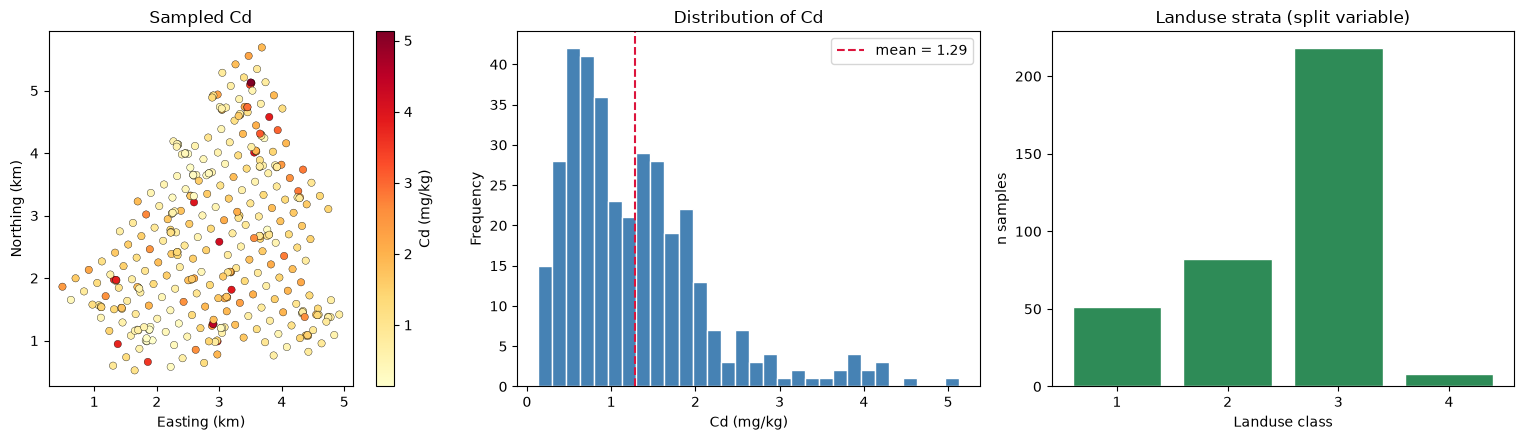

Grid extent: X [0.30, 5.10], Y [0.10, 5.90] km  (5957 nodes)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sc = axes[0].scatter(df[x_col], df[y_col], c=z, cmap="YlOrRd", s=28,
                     edgecolors="k", linewidths=0.25)
plt.colorbar(sc, ax=axes[0], label=f"{target} (mg/kg)")
axes[0].set_title(f"Sampled {target}")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")
axes[0].set_aspect("equal")

axes[1].hist(z, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(z.mean(), color="crimson", ls="--", label=f"mean = {z.mean():.2f}")
axes[1].set_title(f"Distribution of {target}")
axes[1].set_xlabel(f"{target} (mg/kg)"); axes[1].set_ylabel("Frequency")
axes[1].legend()

land_counts = df[strata_col].value_counts().sort_index()
axes[2].bar(land_counts.index.astype(str), land_counts.values, color="seagreen", edgecolor="white")
axes[2].set_title("Landuse strata (split variable)")
axes[2].set_xlabel("Landuse class"); axes[2].set_ylabel("n samples")

plt.tight_layout(); plt.show()

print(f"Grid extent: X [{grid[x_col].min():.2f}, {grid[x_col].max():.2f}], "
      f"Y [{grid[y_col].min():.2f}, {grid[y_col].max():.2f}] km  ({len(grid)} nodes)")

***
## 6. Stratified Train / Test Split

A purely random split can leave a land-use class under-represented in the test set (class `4` has only 8 samples). **Stratified random sampling** draws the 70% / 30% split *inside each Landuse class*, so the class proportions are preserved.

The variogram is estimated from the **training** set only. Ordinary kriging does not use a global mean, but the same split is used so results can be compared with Tutorial 03 (simple kriging).

In [5]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(sss.split(df, df[strata_col]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

coords_train = df_train[[x_col, y_col]].values
coords_test  = df_test[[x_col, y_col]].values
z_train = df_train[target].values.astype(float)
z_test  = df_test[target].values.astype(float)

print(f"Train: {len(df_train)} ({100*len(df_train)/len(df):.1f}%)")
print(f"Test:  {len(df_test)} ({100*len(df_test)/len(df):.1f}%)")
print(f"Training mean of {target} (not used by OK): {z_train.mean():.4f} mg/kg")

prop = pd.DataFrame({
    "all":    df[strata_col].value_counts(normalize=True).sort_index(),
    "train":  df_train[strata_col].value_counts(normalize=True).sort_index(),
    "test":   df_test[strata_col].value_counts(normalize=True).sort_index(),
})
prop.index.name = "Landuse"
(prop * 100).round(1)

Train: 251 (69.9%)
Test:  108 (30.1%)
Training mean of Cd (not used by OK): 1.2995 mg/kg


,all,train,test
Landuse,,,
1,14.2,14.3,13.9
2,22.8,22.7,23.1
3,60.7,60.6,61.1
4,2.2,2.4,1.9


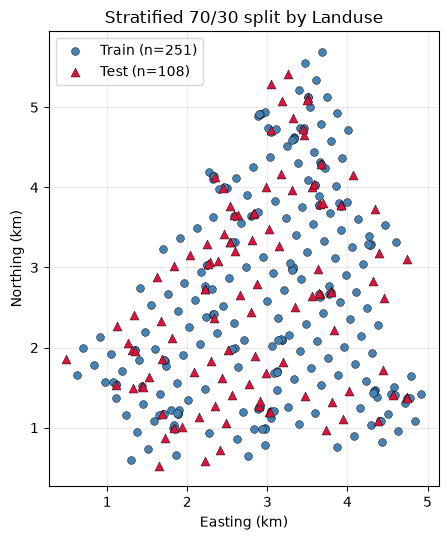

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(df_train[x_col], df_train[y_col], c="steelblue", s=32,
           edgecolors="k", linewidths=0.3, label=f"Train (n={len(df_train)})", zorder=3)
ax.scatter(df_test[x_col], df_test[y_col], c="crimson", s=42, marker="^",
           edgecolors="k", linewidths=0.3, label=f"Test (n={len(df_test)})", zorder=4)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title("Stratified 70/30 split by Landuse")
ax.legend(frameon=True); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

***
## 7. Variogram Modeling on Training Data

We fit all six PyGStat models to the **training** Cd values with the Matheron estimator, then rank them by AIC (Tutorial 02). The winning model is the covariance structure used for ordinary kriging.

In [7]:
def find_best_variogram(coords, values, estimator="matheron", n_lags=15,
                        criterion="AIC", verbose=True):
    """Fit all standard models; return the best Variogram by ``criterion``."""
    models = ["spherical", "exponential", "gaussian", "matern", "stable", "cubic"]
    n_params = {"spherical": 3, "exponential": 3, "gaussian": 3,
                "matern": 4, "stable": 4, "cubic": 3}
    fitted, records = {}, []

    for model_name in models:
        v = Variogram(coords=np.asarray(coords, dtype=float),
                      values=np.asarray(values, dtype=float),
                      model=model_name, estimator=estimator, n_lags=n_lags)
        v.fit()
        obs = v.experimental
        mask = ~np.isnan(obs)
        obs_v, pred = obs[mask], v(v.lags)[mask]
        K, p = mask.sum(), n_params[model_name]
        rss = float(np.sum((pred - obs_v) ** 2))
        tss = float(np.sum((obs_v - obs_v.mean()) ** 2))
        r2 = 1.0 - rss / tss if tss > 0 else np.nan
        aic = K * np.log(rss / K) + 2 * p if rss > 0 else -np.inf
        bic = K * np.log(rss / K) + p * np.log(K) if rss > 0 else -np.inf
        fitted[model_name] = v
        extra = round(float(v.fitted_params[3]), 4) if len(v.fitted_params) > 3 else "—"
        records.append({
            "Model": model_name.capitalize(),
            "Nugget": round(float(v.fitted_params[0]), 5),
            "Sill":   round(float(v.fitted_params[1]), 5),
            "Range":  round(float(v.fitted_params[2]), 5),
            "Extra":  extra,
            "RSS":    round(rss, 6),
            "R²":     round(r2, 4),
            "AIC":    round(aic, 4),
            "BIC":    round(bic, 4),
        })

    df_results = pd.DataFrame(records).set_index("Model")
    df_results = df_results.sort_values(criterion, ascending=(criterion != "R²"))
    best_cap = df_results.index[0]
    best_key = best_cap.lower()
    if verbose:
        print(df_results.to_string())
        print(f"\n>>> BEST MODEL: {best_cap} (by {criterion}) <<<")
    return best_cap, fitted[best_key], df_results, fitted


best_name, vg_best, df_rank, fitted_models = find_best_variogram(
    coords_train, z_train, estimator="matheron", n_lags=12, criterion="AIC"
)

              Nugget     Sill    Range   Extra       RSS      R²      AIC      BIC
Model                                                                             
Spherical    0.56002  0.15320  1.75505       —  0.032596  0.4580 -64.9017 -63.4470
Cubic        0.57964  0.13343  2.06349       —  0.033115  0.4494 -64.7121 -63.2574
Exponential  0.54989  0.19668  0.97775       —  0.033137  0.4490 -64.7041 -63.2493
Gaussian     0.57923  0.13395  0.84831       —  0.033317  0.4460 -64.6390 -63.1842
Matern       0.56645  0.15393  0.39814  1.3931  0.032745  0.4555 -62.8469 -60.9073
Stable       0.56456  0.15532  0.81914  1.4358  0.032843  0.4539 -62.8111 -60.8715

>>> BEST MODEL: Spherical (by AIC) <<<


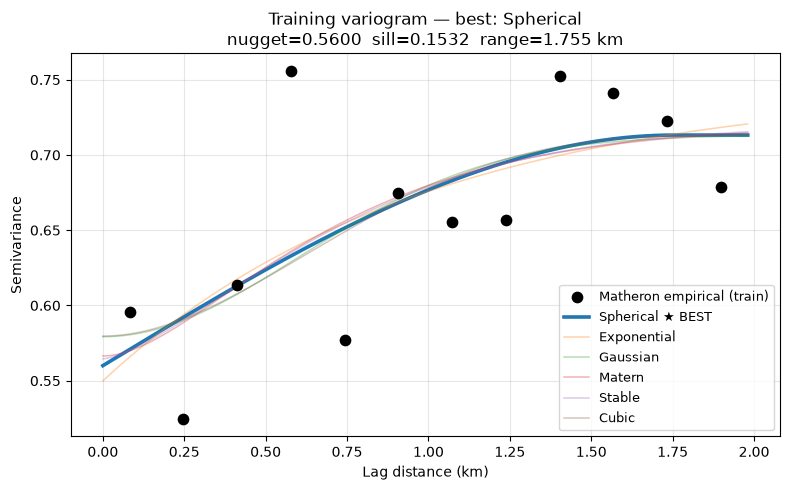

,Nugget,Sill,Range,Extra,RSS,R²,AIC,BIC
Model,,,,,,,,
Spherical,0.560020,0.153200,1.755050,—,0.032596,0.458000,-64.901700,-63.447000
Cubic,0.579640,0.133430,2.063490,—,0.033115,0.449400,-64.712100,-63.257400
Exponential,0.549890,0.196680,0.977750,—,0.033137,0.449000,-64.704100,-63.249300
Gaussian,0.579230,0.133950,0.848310,—,0.033317,0.446000,-64.639000,-63.184200
Matern,0.566450,0.153930,0.398140,1.393100,0.032745,0.455500,-62.846900,-60.907300
Stable,0.564560,0.155320,0.819140,1.435800,0.032843,0.453900,-62.811100,-60.871500


In [8]:
h_fine = np.linspace(0, vg_best.maxlag, 300)
palette = {"Spherical": "#1f77b4", "Exponential": "#ff7f0e", "Gaussian": "#2ca02c",
           "Matern": "#d62728", "Stable": "#9467bd", "Cubic": "#8c564b"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(vg_best.lags, vg_best.experimental, color="black", s=55, zorder=6,
           label="Matheron empirical (train)")
for name, v in fitted_models.items():
    cap = name.capitalize()
    is_best = cap == best_name
    ax.plot(h_fine, v(h_fine), color=palette.get(cap, "gray"),
            lw=2.6 if is_best else 1.1,
            alpha=1.0 if is_best else 0.35,
            label=cap + (" ★ BEST" if is_best else ""))
p = vg_best.fitted_params
ax.set_title(f"Training variogram — best: {best_name}\n"
             f"nugget={p[0]:.4f}  sill={p[1]:.4f}  range={p[2]:.3f} km")
ax.set_xlabel("Lag distance (km)"); ax.set_ylabel("Semivariance")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

df_rank.style.background_gradient(subset=["AIC", "RSS"], cmap="RdYlGn_r")

***
## 8. Fit Ordinary Kriging

`OrdinaryKriging` takes only a fitted `Variogram`. No mean is passed: the unbiasedness constraint estimates the local mean at each prediction location. `use_gpu=USE_GPU` builds the covariance matrix and solves the OK system on CuPy when a usable GPU is present.


In [9]:
ok = OrdinaryKriging(vg_best, use_gpu=USE_GPU).fit(coords_train, z_train)

print(f"Estimator              : Ordinary Kriging")
print(f"Variogram model        : {vg_best.model}")
print(f"Fitted params [C0, C, a]: {np.round(vg_best.fitted_params[:3], 5)}")
print(f"Training n             : {len(z_train)}")
print(f"Mean is not supplied   : OK enforces sum(weights) = 1")
print(f"use_gpu                : {ok.use_gpu}")


Estimator              : Ordinary Kriging
Variogram model        : spherical
Fitted params [C0, C, a]: [0.56002 0.1532  1.75505]
Training n             : 251
Mean is not supplied   : OK enforces sum(weights) = 1
use_gpu                : True


***
## 9. Validate OK on the Test Set

Predict Cd at the **held-out** 30% of samples. These locations were not used to fit the variogram, so the scores below are an honest check of interpolation skill.

In [10]:
z_hat, se_test = ok.predict(coords_test, return_variance=True)

rmse = float(np.sqrt(mean_squared_error(z_test, z_hat)))
mae  = float(mean_absolute_error(z_test, z_hat))
r2   = float(r2_score(z_test, z_hat))
me   = float(np.mean(z_hat - z_test))          # mean error (bias)
resid = z_hat - z_test

print("Ordinary Kriging — test-set validation")
print("=" * 44)
print(f"  n test     : {len(z_test)}")
print(f"  RMSE       : {rmse:.4f} mg/kg")
print(f"  MAE        : {mae:.4f} mg/kg")
print(f"  Mean error : {me:+.4f} mg/kg  (predicted − observed)")
print(f"  R²         : {r2:.4f}")
print(f"  Mean OK SE : {se_test.mean():.4f} mg/kg")

metrics = pd.DataFrame([{
    "n_train": len(z_train), "n_test": len(z_test),
    "model": best_name, "estimator": "ordinary",
    "RMSE": round(rmse, 4), "MAE": round(mae, 4),
    "ME": round(me, 4), "R2": round(r2, 4),
}])
metrics

Ordinary Kriging — test-set validation
  n test     : 108
  RMSE       : 0.8026 mg/kg
  MAE        : 0.5944 mg/kg
  Mean error : +0.0022 mg/kg  (predicted − observed)
  R²         : 0.1836
  Mean OK SE : 0.7874 mg/kg


,n_train,n_test,model,estimator,RMSE,MAE,ME,R2
0,251,108,Spherical,ordinary,0.8026,0.5944,0.0022,0.1836


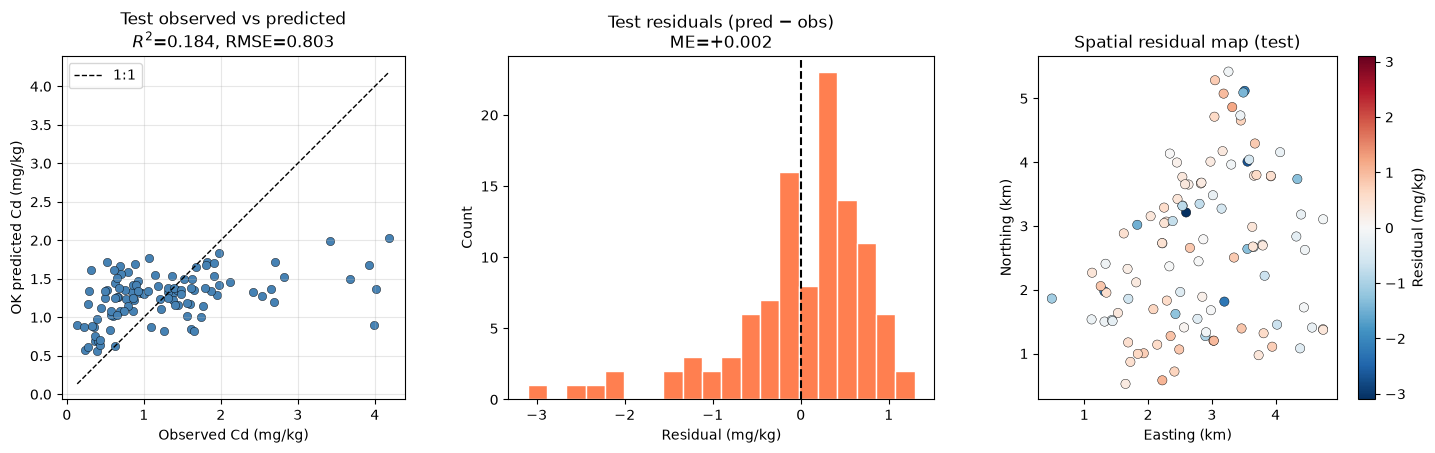

Standardized residual mean: +0.002   std: 1.021  (ideal: 0, 1)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

lo, hi = min(z_test.min(), z_hat.min()), max(z_test.max(), z_hat.max())
axes[0].scatter(z_test, z_hat, c="steelblue", edgecolors="k", linewidths=0.3, s=36)
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
axes[0].set_xlabel("Observed Cd (mg/kg)"); axes[0].set_ylabel("OK predicted Cd (mg/kg)")
axes[0].set_title(f"Test observed vs predicted\n$R^2$={r2:.3f}, RMSE={rmse:.3f}")
axes[0].set_aspect("equal", adjustable="box"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=20, color="coral", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title(f"Test residuals (pred − obs)\nME={me:+.3f}")
axes[1].set_xlabel("Residual (mg/kg)"); axes[1].set_ylabel("Count")

sc = axes[2].scatter(df_test[x_col], df_test[y_col], c=resid, cmap="RdBu_r",
                     s=45, edgecolors="k", linewidths=0.3,
                     vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)))
plt.colorbar(sc, ax=axes[2], label="Residual (mg/kg)")
axes[2].set_aspect("equal")
axes[2].set_title("Spatial residual map (test)")
axes[2].set_xlabel("Easting (km)"); axes[2].set_ylabel("Northing (km)")

plt.tight_layout(); plt.show()

std_resid = resid / np.clip(se_test, 1e-8, None)
print(f"Standardized residual mean: {std_resid.mean():+.3f}   std: {std_resid.std():.3f}  (ideal: 0, 1)")

***
## 10. Predict Cd on the Jura Grid

Apply the same fitted OK model to every node in `jura_grid.csv`. We keep both the predicted concentration and the kriging standard error.

In [12]:
pred_grid, se_grid = ok.predict(grid_coords, return_variance=True)

grid_out = grid.copy()
grid_out["Cd_pred"] = pred_grid
grid_out["Cd_se"] = se_grid

print(f"Grid predictions: n = {len(pred_grid)}")
print(f"  Cd_pred  min/mean/max : {pred_grid.min():.3f} / {pred_grid.mean():.3f} / {pred_grid.max():.3f} mg/kg")
print(f"  Cd_se    min/mean/max : {se_grid.min():.3f} / {se_grid.mean():.3f} / {se_grid.max():.3f} mg/kg")
grid_out[[x_col, y_col, "Cd_pred", "Cd_se"]].head()

Grid predictions: n = 5957
  Cd_pred  min/mean/max : 0.556 / 1.327 / 2.014 mg/kg
  Cd_se    min/mean/max : 0.774 / 0.792 / 0.844 mg/kg


,Xloc,Yloc,Cd_pred,Cd_se
0,0.30,1.70,1.285703,0.827403
1,0.35,1.70,1.286858,0.824101
2,0.35,1.75,1.293433,0.823923
3,0.40,1.70,1.286507,0.820580
4,0.40,1.75,1.295036,0.820410


***
## 11. Map Predicted Concentration and Error

The left map is the OK estimate of Cd. The right map is the **prediction error** (kriging standard error). Error is smallest near training samples and grows toward the edges of the domain and in sparsely sampled pockets. Because OK estimates a local mean, the SE is typically a little larger than the corresponding simple-kriging SE (Tutorial 03).

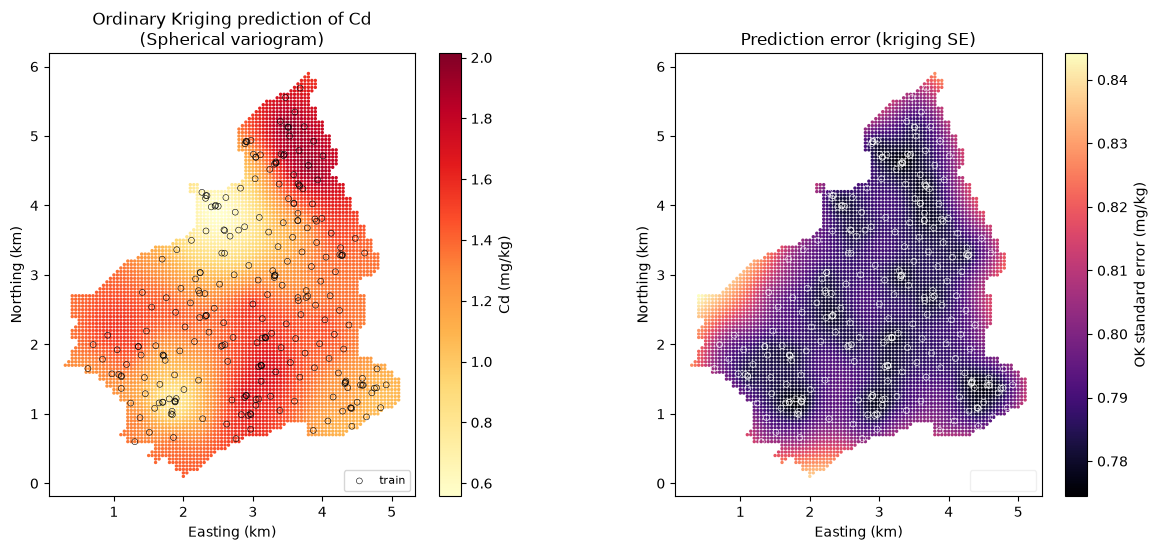

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

sc0 = axes[0].scatter(grid_out[x_col], grid_out[y_col], c=grid_out["Cd_pred"],
                      cmap="YlOrRd", s=8, marker=".")
axes[0].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
                s=18, linewidths=0.4, label="train")
plt.colorbar(sc0, ax=axes[0], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_aspect("equal")
axes[0].set_title(f"Ordinary Kriging prediction of Cd\n({best_name} variogram)")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")
axes[0].legend(loc="lower right", fontsize=8)

sc1 = axes[1].scatter(grid_out[x_col], grid_out[y_col], c=grid_out["Cd_se"],
                      cmap="magma", s=8, marker=".")
axes[1].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="w",
                s=18, linewidths=0.4, label="train")
plt.colorbar(sc1, ax=axes[1], label="OK standard error (mg/kg)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_title("Prediction error (kriging SE)")
axes[1].set_xlabel("Easting (km)"); axes[1].set_ylabel("Northing (km)")
axes[1].legend(loc="lower right", fontsize=8, labelcolor="white", framealpha=0.3)

plt.tight_layout(); plt.show()

***
## 12. Probability Maps of Exceedance

Under the Gaussian OK model,

$$
P(\text{Cd}(\mathbf{x}_0) > z_c) = 1 - \Phi\!\left(\frac{z_c - \hat{Z}_{\text{OK}}(\mathbf{x}_0)}{\sigma_{\text{OK}}(\mathbf{x}_0)}\right).
$$

We map this probability for cutoffs **0.10, 0.25, 0.50, 0.75, and 1.00 mg/kg**. Values near 1 mean Cd is almost surely above the cutoff; values near 0 mean it is almost surely below.

Because the sample mean of Cd is about 1.3 mg/kg, probabilities of exceeding 0.10–0.75 mg/kg will be high over much of the domain. The 1.00 mg/kg map is the most spatially informative of this set.

In [14]:
cutoffs = [0.10, 0.25, 0.50, 0.75, 1.00]   # mg/kg
se_safe = np.clip(se_grid, 1e-8, None)

prob_cols = []
for zc in cutoffs:
    col = f"P_Cd_gt_{zc:.2f}".replace(".", "p")
    grid_out[col] = 1.0 - norm.cdf((zc - pred_grid) / se_safe)
    prob_cols.append(col)
    print(f"P(Cd > {zc:4.2f})  mean={grid_out[col].mean():.3f}  "
          f"min={grid_out[col].min():.3f}  max={grid_out[col].max():.3f}")

emp = {zc: float(np.mean(z_train > zc)) for zc in cutoffs}
print("\nEmpirical P(Cd > zc) on training samples:")
for zc, p in emp.items():
    print(f"  {zc:4.2f} mg/kg : {p:.3f}")

P(Cd > 0.10)  mean=0.929  min=0.721  max=0.993
P(Cd > 0.25)  mean=0.901  min=0.653  max=0.988
P(Cd > 0.50)  mean=0.839  min=0.529  max=0.973
P(Cd > 0.75)  mean=0.756  min=0.402  max=0.947
P(Cd > 1.00)  mean=0.653  min=0.285  max=0.902

Empirical P(Cd > zc) on training samples:
  0.10 mg/kg : 1.000
  0.25 mg/kg : 0.976
  0.50 mg/kg : 0.873
  0.75 mg/kg : 0.701
  1.00 mg/kg : 0.546


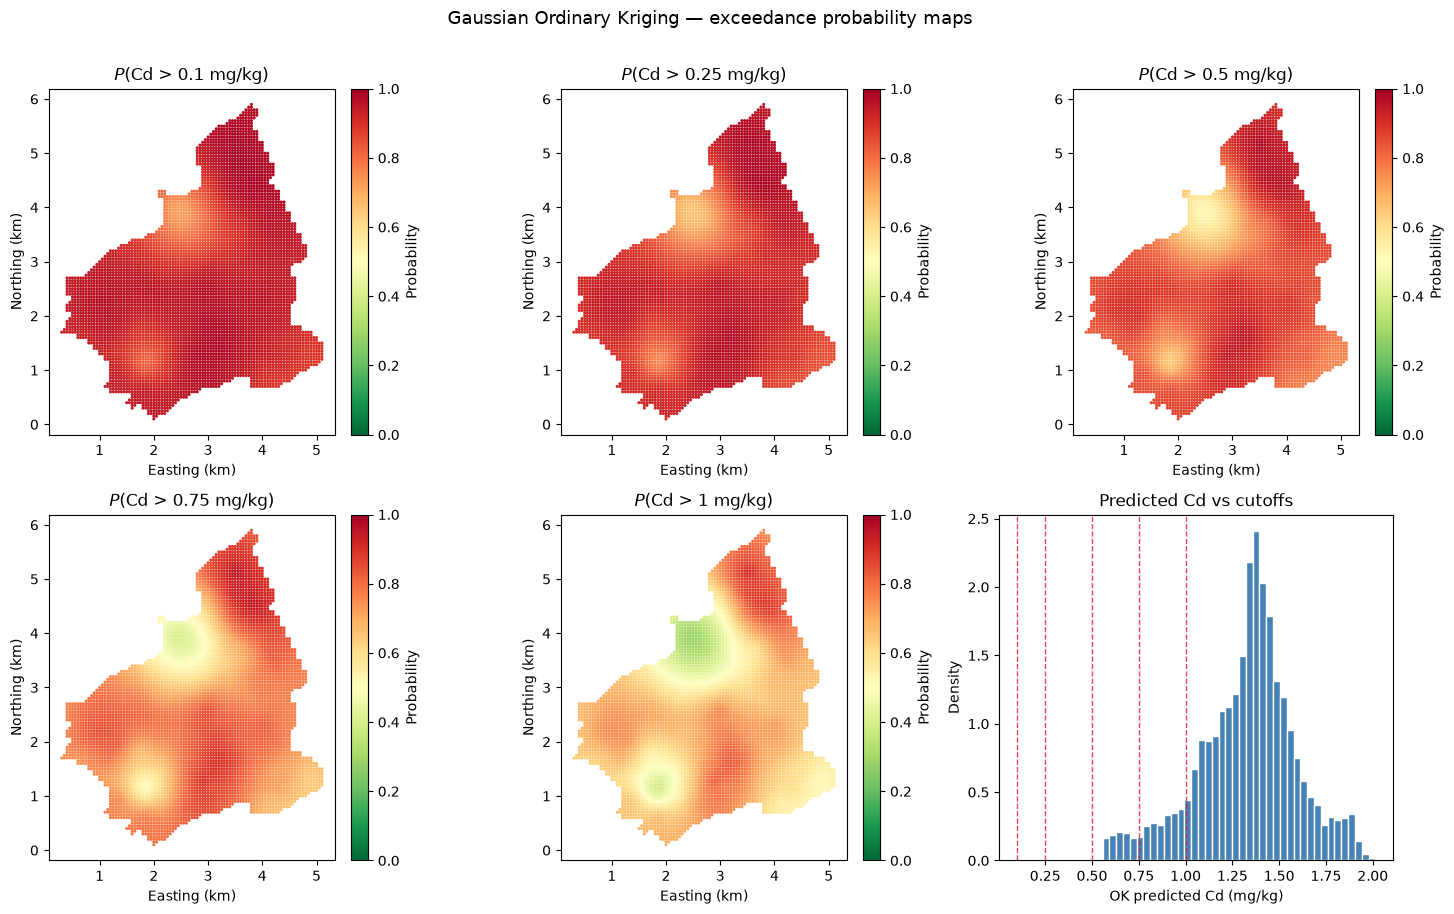

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, zc, col in zip(axes, cutoffs, prob_cols):
    sc = ax.scatter(grid_out[x_col], grid_out[y_col], c=grid_out[col],
                    cmap="RdYlGn_r", s=6, marker=".", vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Probability")
    ax.set_aspect("equal")
    ax.set_title(f"$P$(Cd > {zc:g} mg/kg)")
    ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")

axes[5].hist(pred_grid, bins=40, color="steelblue", edgecolor="white", density=True)
for zc in cutoffs:
    axes[5].axvline(zc, color="crimson", ls="--", lw=1, alpha=0.8)
axes[5].set_title("Predicted Cd vs cutoffs")
axes[5].set_xlabel("OK predicted Cd (mg/kg)"); axes[5].set_ylabel("Density")

plt.suptitle("Gaussian Ordinary Kriging — exceedance probability maps", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [16]:
# Test-set calibration: Brier score for each cutoff (lower is better)
se_test_safe = np.clip(se_test, 1e-8, None)
rows = []
for zc in cutoffs:
    p_hat = 1.0 - norm.cdf((zc - z_hat) / se_test_safe)
    y_ind = (z_test > zc).astype(float)
    brier = float(np.mean((p_hat - y_ind) ** 2))
    rows.append({
        "cutoff_mgkg": zc,
        "empirical_rate_test": round(float(y_ind.mean()), 3),
        "mean_predicted_P": round(float(p_hat.mean()), 3),
        "Brier": round(brier, 4),
    })
pd.DataFrame(rows).set_index("cutoff_mgkg")

,empirical_rate_test,mean_predicted_P,Brier
cutoff_mgkg,,,
0.10,1.000,0.915,0.0111
0.25,0.972,0.884,0.0332
0.50,0.824,0.817,0.1119
0.75,0.639,0.728,0.2025
1.00,0.509,0.623,0.2372


***
## 13. CPU vs GPU OK Timing

Section 4.1 showed how to *select* a backend. Here we measure how long **ordinary kriging** takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) — first on the Jura samples ($n_{\text{train}} = 359$) predicting the Jura grid, then on prefixes of the Great Plains soil-organic-carbon survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The GPU-accelerated steps are the $n \times n$ covariance matrix among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** OK system (ones row/column plus Lagrange multiplier). Variogram fitting is done once per dataset (spherical model) and is **not** included in the OK times.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the OK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `OrdinaryKriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of OK fit + predict)
Jura Cd    : 359 samples → 5957 grid nodes
GP SOC     : 5000 samples from data/gp_data_5000.csv
GP n_pred  : 500 locations drawn from each prefix

  dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
Jura (Cd)      359    5957     162.3      18.5   8.77×   True
 GP (SOC)      500     500      46.3      10.3   4.49×   True
 GP (SOC)     1000     500     150.8      24.4   6.19×   True
 GP (SOC)     2000     500     384.9      65.7   5.85×   True
 GP (SOC)     4000     500    1363.0     209.0   6.52×   True
 GP (SOC)     5000     500    2179.9     361.0   6.04×   True


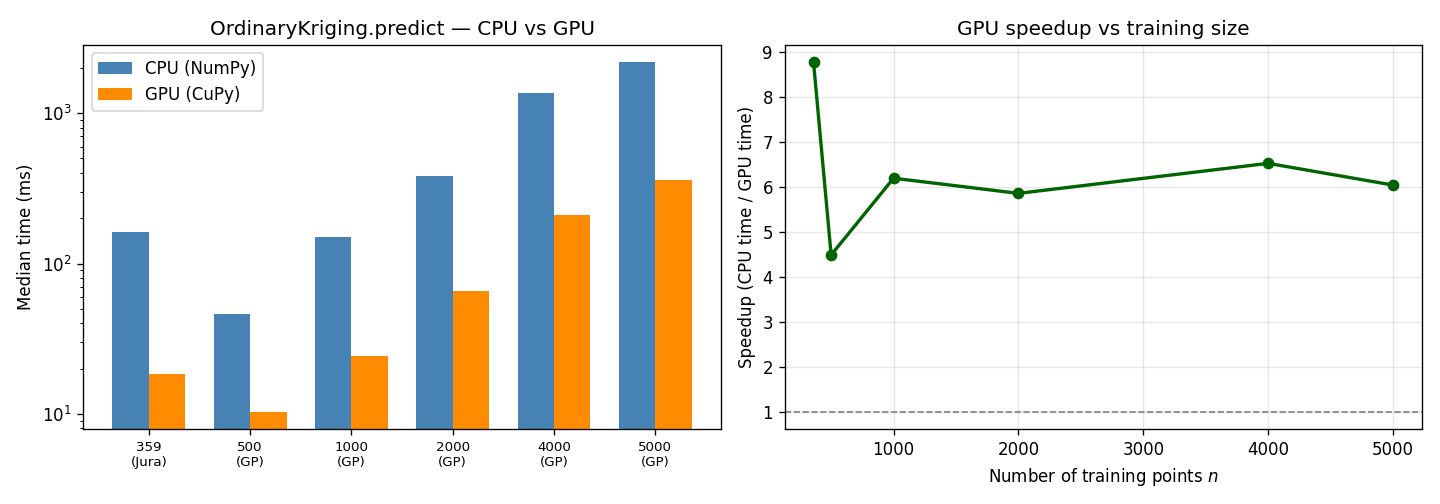

In [17]:
import time

N_LAGS = 12
N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]

df_gp = pd.read_csv("../data/gp_data_5000.csv")
gp_coords = df_gp[["x", "y"]].to_numpy(dtype=float)
gp_vals = df_gp["SOC"].to_numpy(dtype=float)
rng = np.random.default_rng(42)


def _fit_spherical(xy, values, use_gpu=False):
    return Variogram(
        np.asarray(xy, dtype=float),
        np.asarray(values, dtype=float),
        model="spherical",
        n_lags=N_LAGS,
        use_gpu=use_gpu,
    ).fit()


def _time_ok(xy_train, z_train, xy_pred, vg, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of OrdinaryKriging.fit + predict(return_variance=True)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        OrdinaryKriging(vg, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr]
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ok_m = OrdinaryKriging(vg, use_gpu=use_gpu).fit(xy_train, z_train)
        last = ok_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


jobs = [{
    "dataset": "Jura (Cd)",
    "n_obs": len(coords),
    "xy_train": np.asarray(coords, dtype=float),
    "z_train": np.asarray(z, dtype=float),
    "xy_pred": np.asarray(grid_coords, dtype=float),
}]
for n in GP_SIZES:
    n_pred = min(N_PRED_GP, n)
    pred_idx = rng.choice(n, size=n_pred, replace=False)
    jobs.append({
        "dataset": "GP (SOC)",
        "n_obs": n,
        "xy_train": gp_coords[:n],
        "z_train": gp_vals[:n],
        "xy_pred": gp_coords[pred_idx],
    })

print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of OK fit + predict)")
print(f"Jura Cd    : {len(coords)} samples → {len(grid_coords)} grid nodes")
print(f"GP SOC     : {len(gp_vals)} samples from data/gp_data_5000.csv")
print(f"GP n_pred  : {N_PRED_GP} locations drawn from each prefix")
print()

rows = []
for job in jobs:
    xy_tr, z_tr, xy_pr = job["xy_train"], job["z_train"], job["xy_pred"]
    vg = _fit_spherical(xy_tr, z_tr, use_gpu=False)

    cpu_t, pred_cpu = _time_ok(xy_tr, z_tr, xy_pr, vg, use_gpu=False)
    row = {
        "dataset": job["dataset"],
        "n_train": len(xy_tr),
        "n_pred": len(xy_pr),
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }

    if USE_GPU:
        gpu_t, pred_gpu = _time_ok(xy_tr, z_tr, xy_pr, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [
    f"{int(n)}\n({ds.split()[0]})"
    for n, ds in zip(n_vals, df_bench["dataset"])
]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("OrdinaryKriging.predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). On this workstation the Jura run still benefits from the GPU because we predict 5{,}957 grid nodes even though $n = 359$ is small. On the Great Plains SOC prefixes the $O(n^2)$ covariance build and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

This tutorial walked through a complete **ordinary kriging** workflow for Jura cadmium.

### What we did

1. Split 359 samples **70 / 30** with **stratified random sampling by Landuse**, so rare land-use class 4 is represented in both sets.
2. Fitted six theoretical variograms on **training Cd only** and selected the best model by **AIC**.
3. Fitted **Ordinary Kriging** with the unbiasedness constraint $\sum\lambda_i = 1$ (unknown mean) and `use_gpu=USE_GPU`.
4. Validated at held-out locations (RMSE, MAE, mean error, $R^2$, residual maps, standardized residuals).
5. Mapped OK predictions and kriging standard errors on `jura_grid.csv`.
6. Converted $(\hat{Z},\sigma_{\text{OK}})$ into **Gaussian exceedance probabilities** at 0.10, 0.25, 0.50, 0.75, and 1.00 mg/kg, and checked them on the test set with the Brier score.
7. Timed `OrdinaryKriging.predict` on **CPU vs GPU** for Jura Cd and prefixes of `data/gp_data_5000.csv`.

### Practical takeaways

- **Do not leak the test set** into the variogram. OK does not need a global mean, but the covariance model must still be trained only on the training sample.
- OK is the **default interpolator** when the mean is unknown or only locally constant. Use simple kriging (Tutorial 02) only when you trust a global mean.
- The extra Lagrange multiplier makes OK variance slightly **larger** than SK variance — that extra uncertainty is the price of not knowing $m$.
- The **prediction-error map** is not a map of Cd; it shows how well the data constrain the estimate.
- Gaussian $P(\text{Cd} > z_c)$ is a convenient OK by-product. Cd is right-skewed, so these probabilities are an approximation. For a distribution-free alternative, use **indicator kriging**.
- A GPU pays off for OK when $n$ is large *or* you predict a dense grid. Small $n$ with few targets is often CPU-bound after host–device copies.

### Next steps

- Compare test RMSE and mean SE with Tutorial 02 (simple kriging) on this same split (`random_state=42`)
- Universal kriging if Cd has a trend with coordinates, land use, or rock type
- Indicator kriging for the same five cutoffs without the Gaussian assumption


***
## 15. Resources

### Textbooks

| Reference | Notes |
|-----------|-------|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | Jura Cd case study; OK as the default interpolator |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | OK system, Lagrange multiplier, intrinsic hypothesis |
| Isaaks, E.H. & Srivastava, R.M. (1989). *An Introduction to Applied Geostatistics*. Oxford. | Worked OK examples |
| Webster, R. & Oliver, M.A. (2007). *Geostatistics for Environmental Scientists* (2nd ed.). Wiley. | Applied ordinary kriging |

### Key papers

| Paper | Contribution |
|-------|----------------|
| Matheron, G. (1963). Principles of geostatistics. *Economic Geology* 58, 1246–1266. | Formal OK theory |
| Journel, A.G. & Huijbregts, C.J. (1978). *Mining Geostatistics*. Academic Press. | OK equations in mining practice |
| Cressie, N. (1990). The origins of kriging. *Mathematical Geology* 22, 239–252. | History of the OK system |

### In this library

| Object | Role |
|--------|------|
| `pygstat.Variogram` | Empirical variogram + theoretical fit |
| `pygstat.OrdinaryKriging` | OK with unknown mean; `predict(..., return_variance=True)`; `use_gpu=True|False|'auto'` |
| `pygstat.SimpleKriging` | Known-mean counterpart (Tutorial 02) |
| Tutorial 01 | Variogram models and estimators used here |
| `Tutorial/indicator_kriging_workflow.ipynb` | Non-Gaussian exceedance probabilities |
